# Puzzle

https://thefiddler.substack.com/p/can-you-frame-the-triangle

### This Week’s Fiddler
Congratulations—you just won your school’s tabletop football championship! You flicked your lucky paper football to victory countless times, and would now like to frame it for posterity.

The football is an equilateral triangle with a side length of 1 inch. What is the side length of the smallest square frame that will contain the football?

### This Week’s Eytra Credit
To add a little excitement to the framing process, your new plan is to spin the triangular football by a random angle, and then frame it with a square that is not rotated. That is, the square consists of two perfectly horizontal sides and two perfectly vertical sides.

On average, what can you expect the side length of the smallest resulting square frame to be?

# Solution

I think this is straightforward and the answers can be calculated using wolfram alpha: 

[Step 1](https://www.wolframalpha.com/input?i=solve+cos%28x%29+%3D+sin%28x%2B+%28pi%2F3%29%29)
[Step 2](https://www.wolframalpha.com/input?i=cos%28pi%2F12%29)
Fiddler Answer = (1 + sqrt(3))/(2 sqrt(2)) = 0.9659258262890682867497431997288973676339048390084045504023430763...

[Step 3](https://www.wolframalpha.com/input?i=12%2Fpi+*+%28integral+from+0+to+pi%2F12+%28cos%28x%29%29%29)
Extra Credit Answer = (12 integral_0^(π/12) cos(x) dx)/π = (3 sqrt(2) (sqrt(3) - 1))/π≈0.988615929465369

But I am going to do it myself as well to be extra sure.

Let's place our triangle with one vertex at the origin, and the base originally along the x axis, but rotated by $\theta$. 

The cartesian coordinates of the 3 vertices will be: 
$(0,0) (cos(\theta), sin(\theta)) (cos(\theta+\pi/3), sin(\theta+\pi/3))$

We can find the x-span and the y-span by taking the difference of the min and max x and y values.

The square side length will be the large of the x-span and the y-span.

We have to minimize / average this for the fiddler / EC.

In [4]:
from math import pi, sin, cos

def square_side_len(theta1):
    theta2 = theta1 + (pi/3)
    x0, y0 = 0,0
    x1, y1 = cos(theta1), sin(theta1)
    x2, y2 = cos(theta2), sin(theta2)
    x_span = max(x0,x1,x2) - min(x0,x1,x2)
    y_span = max(y0,y1,y2) - min(y0,y1,y2)
    sq_side = max(x_span, y_span)
    return sq_side

assert(square_side_len(0) == 1)
assert(square_side_len(pi/12) == cos(pi/12))

In [12]:
from scipy.optimize import minimize_scalar

res = minimize_scalar(square_side_len, bounds=(0,pi/2))
print(res)

print(f"\n sq_side_len={res.fun} min value reached at theta={res.x}")

 message: Solution found.
 success: True
  status: 0
     fun: 0.9659260193934036
       x: 0.26180013389804724
     nit: 19
    nfev: 19

 sq_side_len=0.9659260193934036 min value reached at theta=0.26180013389804724


In [26]:
from scipy.integrate import quad

res = quad(square_side_len, 0, 2*pi, epsabs=1e-10, epsrel=1e-10)
print(res)

average_value = res[0]/(2*pi)
print(average_value)

(6.2116570824605075, 4.133369202463655e-10)
0.9886159294653707


Let's also plot this function, just to see how it looks.

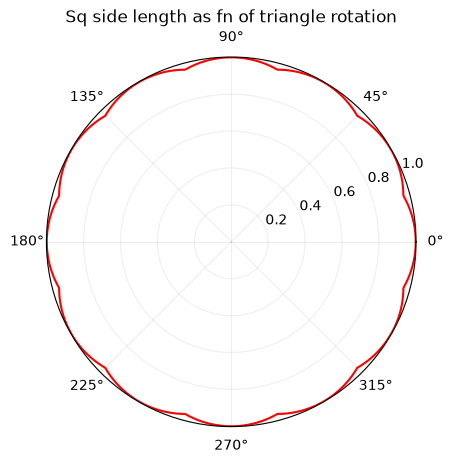

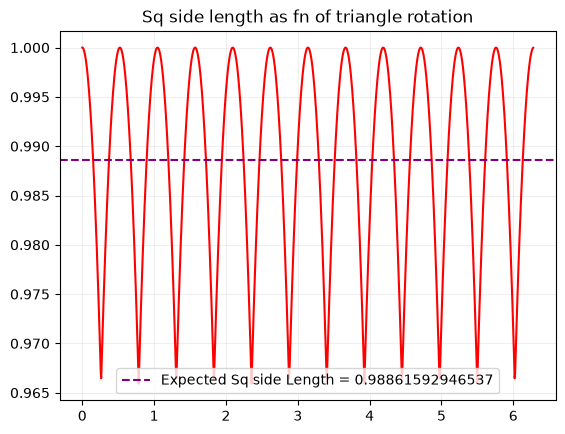

In [48]:
N=1000

thetas = [i*2*pi/N for i in range(N)]
sq_sides = [square_side_len(t) for t in thetas]

import matplotlib.pyplot as plt

plt.polar(thetas, sq_sides, linestyle='-', color='r')
plt.title("Sq side length as fn of triangle rotation")
plt.grid(alpha=0.2)
plt.show()

plt.plot(thetas, sq_sides, linestyle='-', color='r')
plt.title("Sq side length as fn of triangle rotation")
plt.axhline(y=0.98861592946537, color='purple', linestyle='--', label='Expected Sq side Length = 0.98861592946537')
plt.legend()
plt.grid(alpha=0.2)
plt.show()

# Conclusion

Everything seems consistent.

The fiddler answer is 0.965926, reached at the nicely symmetric angle of pi/12 , i.e. equal angles with the x and y axis.

The extra credit answer is 0.9886159.